In [1]:
# 1. Download the inference results if not already downloaded.

# 2. Model checkpoints should be in ../outputs/Cologne-v1/vdn_rnn/

In [2]:
import jax
import jaxmarl

import math
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, LineString
import contextily as cx
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

# Set global plotting parameters (Prateek)
# plt.rcParams.update({
#     "font.size": 8,
#     "font.family": "serif",
#     "font.serif": ["CMU Serif", "DejaVu Serif"],  # first is your CMU, second is fallback
#     "mathtext.fontset": "cm",                     # Computer Modern math
#     "axes.titlesize": 8,
#     "axes.labelsize": 8,
#     "xtick.labelsize": 7,
#     "ytick.labelsize": 7,
#     "legend.fontsize": 7,
#     "text.usetex": False,
# })

# Set global plotting parameters (Daniel H.)
plt.rcParams.update(
    {
        "font.size": 8,
        "font.family": "serif",
        "font.serif": ["Times New Roman"],  # or 'Times'
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "text.usetex": False,
    }
)

from rollout_data_generator import RolloutDataGenerator

In [3]:
ENV_NAME = "Cologne-v1"
ALG = "vdn_rnn"
env = jaxmarl.make("road_env", map_name=ENV_NAME)
rdg = RolloutDataGenerator(ENV_NAME, ALG, test_num_envs=1_000)
key = jax.random.PRNGKey(42)
episode_data = rdg.generate_rollout_data(key)

# get data for a single episode among all the episode_data
seed = 435
single_episdode_data = rdg.get_single_episode_data(episode_data, episode_idx=seed)

Selected best checkpoint dir and id
Extracted outputs path: outputs/Cologne-v1/vdn_rnn/2025-12-18_15-58-42.260314
Using run dir: 2025-12-18_15-58-42.260314, checkpoint id: 23040


In [33]:
class RolloutPlotter:
    """
    This function returns a template to fill the episode data.
    The plotting functions use this stencil to create the data for plotting.
    (This is a replacement for the recorder class in NumPy environment)

    N: number of components
    T: max timesteps
    S: number of damage states
    E: number of edges

    # stencil for the plotting data
    plot_data = {
        "edge_states": [],  #! shape: (T+1, N)
        "edge_observations": [],  #! shape: (T+1, N)
        "edge_beliefs": [],  #! shape: (T+1, S, N)
        "action": [],  # shape: (T, N)
        "applied_actions": [],  # shape: (T, N)
        "total_travel_time": [],  # shape: (T,)
        "travel_times": [],  # shape: (T, E)
        "reward": [],  # shape: (T,)
        "travel_time_reward": [],  # shape: (T,)
        "maintenance_reward": [],  # shape: (T,)
        "terminal_reward": [],  # shape: (T,)
        "budget_remaining": [],  #! shape: (T+1,)
        "budget_constraints_applied": [],  # shape: (T,)
        "forced_replace_constraint_applied": [],  # shape: (T,)
        "traffic_volumes": [],  # shape: (T, E)
        "episode_cost": 0,
    }
    """

    def __init__(self, env):
        self.env = env.env
        self.num_components = env.num_agents
        self.num_damage_states = env.env.num_damage_states
        self.num_component_actions = len(env.env.action_map)
        self.max_timesteps = env.env.max_timesteps
        self.base_total_travel_time = env.env.base_total_travel_time
        self.initial_edge_volumes = None

    def _plot_deterioration(
        self,
        plot_data,
        components_to_show="all",
        show_proposed_actions=True,
        save_kwargs=None,
        fig_width=14,
        fig_height=None,
        ax=None,
        fontsize_scale=None,
    ):

        if components_to_show == "all":
            components_to_show = range(self.num_components)
        elif isinstance(components_to_show, int):
            components_to_show = [components_to_show]
        elif isinstance(components_to_show, list):
            components_to_show = [int(c) for c in components_to_show]
            if any(c >= self.num_components for c in components_to_show):
                raise ValueError(f"components must be less than {self.num_components}")
        else:
            raise ValueError(
                "components must be 'all' or an integer or a list of integers"
            )

        if ax is not None:
            # If an axes is provided, plot a single component on it
            fig = ax.figure
            # Normalize components_to_show to a single integer
            if isinstance(components_to_show, list):
                comp = int(components_to_show[0])
            elif isinstance(components_to_show, int):
                comp = int(components_to_show)
            else:
                comp = 0
            # ticks and labels: actions
            time_horizon_ticks = np.arange(0, self.max_timesteps + 1, 10)
            action_markers = [".", "s", "<", ">", "^"]
            action_labels = [
                "routine inspection",
                "high-fidelity inspection",
                "minor repair",
                "major repair",
                "replace",
            ]
            action_colors = ["gray", "orange", "blue", "dodgerblue", "darkviolet"]
            action_markersize = (
                5 if fontsize_scale is None else max(3, int(5 * fontsize_scale))
            )
            # compute failures over all components once
            plot_data["component_failures"] = np.zeros(
                (self.max_timesteps + 1, self.num_components)
            )
            for t in range(self.max_timesteps + 1):
                plot_data["component_failures"][t, :] = plot_data["edge_states"][
                    t, :
                ] == (self.num_damage_states - 1)
            # state
            (h_true_state,) = ax.plot(
                plot_data["timesteps"],
                plot_data["edge_states"][:, comp],
                "-",
                color="tab:green",
                linewidth=1.1,
                alpha=0.6,
                label="true state",
            )
            # observation
            (h_obs,) = ax.plot(
                plot_data["timesteps"],
                plot_data["edge_observations"][:, comp],
                "-o",
                color="tab:blue",
                markersize=2,
                linewidth=1.0,
                alpha=0.9,
                markerfacecolor="tab:blue",
                markeredgecolor="tab:blue",
                label="inspection outcome",
            )
            # belief heatmap
            ax.pcolormesh(
                plot_data["timesteps"],
                np.arange(self.num_damage_states),
                plot_data["edge_beliefs"][:, comp, :].T,
                shading="nearest",
                cmap="binary",
                alpha=0.2,
                vmin=0,
                vmax=1,
                edgecolors="face",
            )
            # unsafe states
            if plot_data["component_failures"][:, comp].any():
                for _t in np.where(plot_data["component_failures"][:, comp])[0]:
                    ax.axvline(
                        _t, color="red", linestyle="--", alpha=0.6, linewidth=1.0
                    )
            # terminal shaded region
            last_timestep_start = plot_data["timesteps"][-1] - 0.5
            last_timestep_width = (
                plot_data["timesteps"][-1] - plot_data["timesteps"][-2]
            )
            rect = patches.Rectangle(
                (last_timestep_start, -0.5),
                last_timestep_width,
                self.num_damage_states + 1,
                facecolor="hotpink",
                hatch="\\" * 4,
                edgecolor="black",
                alpha=0.1,
            )
            ax.add_patch(rect)
            # actions
            for a in range(self.num_component_actions):
                _x = np.where(plot_data["applied_actions"][:, comp] == a)
                ax.plot(
                    _x,
                    2,
                    action_markers[a],
                    markersize=action_markersize,
                    color=action_colors[a],
                )
                if show_proposed_actions:
                    _x = np.where(plot_data["action"][:, comp] == a)
                    ax.plot(
                        _x,
                        3,
                        action_markers[a],
                        markersize=action_markersize,
                        color=action_colors[a],
                        alpha=0.3,
                    )
            # cosmetics and legend to match style
            ax.set_xlim([-0.5, self.max_timesteps + 0.5])
            ax.set_ylim([-0.5, self.num_damage_states - 0.5])
            ax.grid(axis="y", which="major", alpha=0.3, linewidth=0.6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            # legend handles (compact)
            legend_handles = []
            legend_handles += [h_true_state, h_obs]
            pcolormesh_proxy = patches.Patch(
                facecolor="gray", alpha=0.2, label="damage probs."
            )
            legend_handles += [pcolormesh_proxy]
            if plot_data["component_failures"].any():
                legend_handles += [
                    Line2D([], [], color="red", linestyle="--", label="unsafe state")
                ]
            for a in range(self.num_component_actions):
                legend_handles.append(
                    Line2D(
                        [],
                        [],
                        marker=action_markers[a],
                        linestyle="None",
                        markersize=action_markersize,
                        label=action_labels[a],
                        color=action_colors[a],
                    )
                )
            ax.legend(
                handles=legend_handles,
                loc="upper center",
                ncol=6,
                frameon=True,
                bbox_to_anchor=(0.5, -0.4),
                borderaxespad=0.0,
                columnspacing=0.9,
                handlelength=1.6,
                fontsize=7,
            )
            return

        if len(components_to_show) > 2:
            nrows = math.ceil(len(components_to_show) / 2)
            if fig_height is None:
                fig_height = 0.75 * len(components_to_show)
            fig, _ax = plt.subplots(
                nrows, 2, figsize=(fig_width, fig_height), sharex=True, sharey=True
            )
            _ax = np.atleast_2d(_ax)

        else:
            if fig_height is None:
                fig_height = 2.5
            fig, _ax = plt.subplots(
                1, len(components_to_show), figsize=(fig_width, fig_height)
            )
            _ax = np.array([_ax])

        # ticks and labels: actions
        time_horizon_ticks = np.arange(0, self.max_timesteps + 1, 10)
        action_markers = [".", "s", "<", ">", "^"]
        action_labels = [
            "routine inspection",
            "high-fidelity inspection",
            "minor repair",
            "major repair",
            "replace",
        ]
        action_colors = ["gray", "orange", "blue", "dodgerblue", "darkviolet"]
        action_markersize = 7

        # compute components failure timepoints
        plot_data["component_failures"] = np.zeros(
            (self.max_timesteps + 1, self.num_components)
        )
        for t in range(self.max_timesteps + 1):
            # if damage state is num_damage_states-1, then component has failed
            plot_data["component_failures"][t, :] = plot_data["edge_states"][t, :] == (
                self.num_damage_states - 1
            )

        for c, comp in enumerate(components_to_show):

            if len(components_to_show) > 2:
                ax = _ax[c // 2, c % 2]
            else:
                ax = _ax[c]

            # state
            (h_true_state,) = ax.plot(
                plot_data["timesteps"],
                plot_data["edge_states"][:, comp],
                "-",
                label="true state",
                color="tab:green",
                markersize=2,
                alpha=0.5,
            )

            # observation
            (h_obs,) = ax.plot(
                plot_data["timesteps"],
                plot_data["edge_observations"][:, comp],
                "-o",
                label="inspection outcome",
                color="tab:blue",
                markersize=3,
                alpha=0.8,
            )

            # belief
            ax.pcolormesh(
                plot_data["timesteps"],
                np.arange(self.num_damage_states),
                plot_data["edge_beliefs"][:, comp, :].T,
                shading="nearest",
                cmap="binary",  # _r for reversed
                alpha=0.2,
                vmin=0,
                vmax=1,
                edgecolors="face",
            )

            # draw vertical lines when component fails
            if plot_data["component_failures"][:, comp].any():
                for t in np.where(plot_data["component_failures"][:, comp])[0]:
                    ax.axvline(t, color="red", linestyle="--", alpha=0.5)

            # Highlight the last timestep with hatching
            last_timestep_start = plot_data["timesteps"][-1] - 0.5
            last_timestep_width = (
                plot_data["timesteps"][-1] - plot_data["timesteps"][-2]
            )
            rect = patches.Rectangle(
                (last_timestep_start, -0.5),  # Lower left corner of the rectangle
                last_timestep_width,  # Width of the rectangle (covers last timestep)
                self.num_damage_states + 1,  # Height of the rectangle
                facecolor="hotpink",  # No fill color
                hatch="\\" * 4,  # Hatching pattern
                edgecolor="black",  # Edge color
                alpha=0.1,  # Transparency
                label="terminal state",
            )
            ax.add_patch(rect)

            ## Plot agent actions
            for a in range(self.num_component_actions):
                # applied actions
                _x = np.where(plot_data["applied_actions"][:, comp] == a)
                ax.plot(
                    _x,
                    2,
                    action_markers[a],
                    markersize=action_markersize,
                    label=action_labels[a],
                    color=action_colors[a],
                )

                if show_proposed_actions:
                    # proposed actions
                    _x = np.where(plot_data["action"][:, comp] == a)
                    ax.plot(
                        _x,
                        3,
                        action_markers[a],
                        markersize=action_markersize,
                        color=action_colors[a],
                        alpha=0.3,
                    )

            ax.set_xlim([-0.5, self.max_timesteps + 0.5])
            ax.set_ylim([-0.5, self.num_damage_states - 0.5])
            ax.set_xticks(time_horizon_ticks)
            ax.set_yticks(np.arange(self.num_damage_states))
            ax.set_yticklabels(np.arange(self.num_damage_states, 0, -1))
            ax.tick_params(axis="both", labelsize=14)  # set font size for both axes
            ax.set_xlabel("timestep", fontsize=14)
            ax.set_ylabel("damage state", fontsize=14)
            ax.set_title(
                f"(b) Deterioration, inspection and maintenance | segment: {comp}",
                fontsize=16,
                weight="bold",
            )

            # create legend handles
            legend_handles = []
            for a in range(self.num_component_actions):
                legend_handles += [
                    Line2D(
                        [],
                        [],
                        marker=action_markers[a],
                        markersize=action_markersize,
                        label=action_labels[a],
                        color=action_colors[a],
                        linestyle="None",
                    )
                ]

        legend_handles += [h_true_state, h_obs, rect]
        pcolormesh_proxy = patches.Patch(
            facecolor="gray", alpha=0.2, label="damage probs."
        )
        legend_handles += [pcolormesh_proxy]
        if plot_data["component_failures"].any():
            legend_handles += [
                Line2D([], [], color="red", linestyle="--", label="unsafe state")
            ]

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, -2),  # slightly lower anchor for better spacing
            ncol=5,  # increase columns to prevent crowding
            fontsize=14,
        )

        fig.tight_layout()
        plt.show()

        if save_kwargs is not None:
            fig.savefig(**save_kwargs)

    def _plot_budget(
        self,
        plot_data,
        ax=None,
        save_kwargs=None,
        fig_width=16,
        fig_height=3.2,
    ):

        time = plot_data["timesteps"]

        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height), sharex=True)
        else:
            fig = ax.figure

        percent_remaining = plot_data["budget_remaining"] / self.env.budget_amount * 100
        percent_used = 100 - percent_remaining

        ax.plot(
            time,
            percent_used,
            "-o",
            color="#1f77b4",
            alpha=0.9,
            linewidth=1.2,
            markersize=3.5,
            markerfacecolor="white",
            markeredgewidth=0.8,
        )

        for t in plot_data["timesteps"][:-1]:
            # draw vertical lines for budget renewals
            if t % self.env.budget_renewal_interval == 0:
                ax.axvline(t, color="green", linestyle="--", alpha=0.5, linewidth=1.0)

            # forced replace marker
            if plot_data["forced_replace_constraint_applied"][t]:
                ax.scatter(
                    [t],
                    [50],
                    marker="^",
                    s=40,
                    c="red",
                    edgecolors="white",
                    linewidths=0.8,
                    zorder=5,
                )
                ax.text(
                    t,
                    52,
                    f"({plot_data['forced_replace_constraint_applied'][t]})",
                    fontsize=8,
                    ha="center",
                    va="bottom",
                    color="red",
                    weight="bold",
                )

        # Axes cosmetics to match combined plot
        ax.set_ylim([-2, 105])
        ax.set_xlim([-0.5, self.max_timesteps + 0.5])
        ax.set_ylabel("% of budget used")
        ax.set_xticks(np.arange(0, self.max_timesteps + 1, 10))
        ax.grid(axis="y", which="major", alpha=0.3, linewidth=0.6)
        ax.grid(axis="y", which="minor", alpha=0.15, linewidth=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.margins(x=0)

        # Legend inside axis
        custom_lines = [
            Line2D(
                [],
                [],
                color="blue",
                alpha=0.6,
                label="budget used",
                marker="o",
                linewidth=1.0,
                markersize=3,
            ),
            Line2D(
                [],
                [],
                color="green",
                linestyle="--",
                alpha=0.6,
                label="budget renewal",
                linewidth=1.0,
            ),
            Line2D(
                [],
                [],
                color="red",
                marker="^",
                linestyle="",
                label="forced replace (count)",
                markerfacecolor="red",
                markeredgecolor="white",
                markeredgewidth=0.8,
                markersize=6,
            ),
        ]
        ax.legend(
            handles=custom_lines,
            loc="upper right",
            ncol=3,
            frameon=True,
            bbox_to_anchor=(0.95, 1.0),
            borderaxespad=0.0,
            handlelength=2.0,
            columnspacing=1.0,
        )

        if save_kwargs is not None and ax is not None:
            fig.savefig(**save_kwargs)

    def _plot_traffic_volume_and_travel_times(
        self, plot_data, components_to_show="all", save_kwargs=None, axes=None
    ):

        if axes is None:
            fig, _ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
            created_fig = True
        else:
            _ax = np.array(axes)
            fig = _ax[0].figure
            created_fig = False

        # Define labels for edges
        if components_to_show == "all":
            components_to_show = range(self.env.graph.ecount())
        elif isinstance(components_to_show, int):
            components_to_show = [components_to_show]
        elif isinstance(components_to_show, list):
            components_to_show = [int(c) for c in components_to_show]
            if any(c >= self.env.graph.ecount() for c in components_to_show):
                raise ValueError(
                    f"components must be less than {self.env.graph.ecount()}"
                )
        else:
            raise ValueError(
                "components must be 'all' or an integer or a list of integers"
            )

        # ticks and labels: actions
        time_horizon_ticks = np.arange(0, self.max_timesteps + 1, 10)
        action_markers = [".", "s", "<", ">", "^"]
        action_labels = [
            "routine inspection",
            "high-fidelity inspection",
            "minor repair",
            "major repair",
            "replace",
        ]
        action_colors = ["gray", "orange", "blue", "dodgerblue", "darkviolet"]
        action_markersize = 7

        labels = [f"edge {i}" for i in components_to_show]
        try:
            color_list = plt.colormaps["tab10"](
                np.linspace(0, 1, len(components_to_show))
            )
        except Exception:
            color_list = plt.cm.get_cmap("tab10", len(components_to_show))(
                np.arange(len(components_to_show))
            )

        if not created_fig:
            # Combined-plot styling: support single or multiple components
            if isinstance(components_to_show, (list, tuple)):
                comps = [int(c) for c in components_to_show]
            elif isinstance(components_to_show, int):
                comps = [int(components_to_show)]
            else:
                comps = [0]

            if len(comps) == 1:
                comp = comps[0]
                vol_pct = (
                    plot_data["traffic_volumes"][:, comp]
                    * 100
                    / self.env.initial_capacities[comp]
                )
                tt_pct = (
                    plot_data["travel_times"][:, comp]
                    * 100
                    / self.env.initial_btts[comp]
                )
                _ax[0].plot(
                    plot_data["timesteps"][:-1],
                    vol_pct,
                    color="tab:orange",
                    linewidth=1.2,
                    marker="o",
                    markersize=3,
                    markerfacecolor="white",
                    markeredgewidth=0.8,
                )
                _ax[0].axhline(
                    100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
                )
                _lo = float(vol_pct.min())
                _hi = float(vol_pct.max())
                _span = max(1.0, _hi - _lo)
                _pad = max(2.0, 0.05 * _span)
                _ymin = max(0.0, _lo - _pad)
                _ymax = max(100.0 + _pad, _hi + _pad)
                _ax[0].set_ylim(_ymin, min(105.0, _ymax))
                _ax[0].margins(x=0)
                _ax[0].grid(axis="y", which="major", alpha=0.3, linewidth=0.6)
                _ax[0].spines["top"].set_visible(False)
                _ax[0].spines["right"].set_visible(False)
                # applied actions as mid-row markers (same scheme as deterioration)
                ymin, ymax = _ax[0].get_ylim()
                y_middle = (ymax + ymin) / 2
                for a in range(self.num_component_actions):
                    _x = np.where(plot_data["applied_actions"][:, comp] == a)
                    _ax[0].plot(
                        _x,
                        y_middle,
                        action_markers[a],
                        markersize=4,
                        color=action_colors[a],
                    )
                _ax[1].plot(
                    plot_data["timesteps"][:-1],
                    tt_pct,
                    color="tab:blue",
                    linewidth=1.2,
                    marker="x",
                    markersize=3,
                    markeredgewidth=0.8,
                )
                _ax[1].axhline(
                    100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
                )
                _lo = float(tt_pct.min())
                _hi = float(tt_pct.max())
                _span = max(1.0, _hi - _lo)
                _pad = max(2.0, 0.05 * _span)
                _ymin = max(0.0, _lo - _pad)
                _ymax = max(100.0 + _pad, _hi + _pad)
                _ax[1].set_ylim(_ymin, _ymax)
                _ax[1].margins(x=0)
                _ax[1].grid(axis="y", which="major", alpha=0.3, linewidth=0.6)
                _ax[1].spines["top"].set_visible(False)
                _ax[1].spines["right"].set_visible(False)
                # applied actions on travel time panel
                ymin, ymax = _ax[1].get_ylim()
                y_middle = (ymax + ymin) / 2
                for a in range(self.num_component_actions):
                    _x = np.where(plot_data["applied_actions"][:, comp] == a)
                    _ax[1].plot(
                        _x,
                        y_middle,
                        action_markers[a],
                        markersize=4,
                        color=action_colors[a],
                    )
            else:
                vol_series = []
                tt_series = []
                for c, comp in enumerate(comps):
                    vol_pct = (
                        plot_data["traffic_volumes"][:, comp]
                        * 100
                        / self.env.initial_capacities[comp]
                    )
                    tt_pct = (
                        plot_data["travel_times"][:, comp]
                        * 100
                        / self.env.initial_btts[comp]
                    )
                    vol_series.append(vol_pct)
                    tt_series.append(tt_pct)
                    _ax[0].plot(
                        plot_data["timesteps"][:-1], vol_pct, color=color_list[c], linewidth=0.8, alpha=0.6
                    )
                    _ax[1].plot(
                        plot_data["timesteps"][:-1], tt_pct, color=color_list[c], linewidth=0.8, alpha=0.6
                    )

                _ax[0].axhline(
                    100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
                )
                _ax[1].axhline(
                    100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
                )

                vol_all = np.concatenate(vol_series)
                tt_all = np.concatenate(tt_series)
                _vmin, _vmax = float(vol_all.min()), float(vol_all.max())
                _tmin, _tmax = float(tt_all.min()), float(tt_all.max())
                _vspan = max(1.0, _vmax - _vmin)
                _vpad = max(2.0, 0.05 * _vspan)
                _tspan = max(1.0, _tmax - _tmin)
                _tpad = max(2.0, 0.05 * _tspan)

                _ax[0].set_ylim(max(0.0, _vmin - _vpad), min(105.0, _vmax + _vpad))
                _ax[1].set_ylim(max(0.0, _tmin - _tpad), _tmax + _tpad)
                _ax[0].margins(x=0)
                _ax[1].margins(x=0)
                _ax[0].grid(axis="y", which="major", alpha=0.3, linewidth=0.6)
                _ax[1].grid(axis="y", which="major", alpha=0.3, linewidth=0.6)
                _ax[0].spines["top"].set_visible(False)
                _ax[0].spines["right"].set_visible(False)
                _ax[1].spines["top"].set_visible(False)
                _ax[1].spines["right"].set_visible(False)
        else:
            for c, comp in enumerate(components_to_show):
                _ax[0].plot(
                    plot_data["timesteps"],
                    plot_data["traffic_volumes"][:, comp]
                    * 100
                    / self.env.initial_capacities[comp],
                    label=labels[c],
                    color=color_list[c],
                    marker="o",
                    markersize=5,
                    linestyle="-",
                    linewidth=1.5,
                )
                ## Plot agent actions
                ymin, ymax = _ax[0].get_ylim()
                y_middle = (ymax + ymin) / 2
                for a in range(self.num_component_actions):
                    _x = np.where(plot_data["applied_actions"][:, comp] == a)
                    _ax[0].plot(
                        plot_data["timesteps"][_x],
                        np.full_like(plot_data["timesteps"][_x], y_middle, dtype=float),
                        action_markers[a],
                        markersize=action_markersize,
                        label=action_labels[a],
                        color=action_colors[a],
                    )

                _ax[1].plot(
                    plot_data["timesteps"],
                    plot_data["travel_times"][:, comp]
                    * 100
                    / self.env.initial_btts[comp],
                    color=color_list[c],
                    marker="x",
                    markersize=5,
                    linestyle="-",
                    linewidth=1.5,
                )
                ## Plot agent actions
                ymin, ymax = _ax[1].get_ylim()
                y_middle = (ymax + ymin) / 2
                for a in range(self.num_component_actions):
                    _x = np.where(plot_data["applied_actions"][:, comp] == a)
                    _ax[1].plot(
                        plot_data["timesteps"][_x],
                        np.full_like(plot_data["timesteps"][_x], y_middle, dtype=float),
                        action_markers[a],
                        markersize=action_markersize,
                        color=action_colors[a],
                    )

        if created_fig:
            _ax[0].set_title(
                "Traffic volume (as % of capacity)", fontsize=14, fontweight="bold"
            )
            _ax[1].set_title(
                "Travel time (as % of base travel time)", fontsize=14, fontweight="bold"
            )
            _ax[0].set_ylabel(
                r"$\frac{\text{Traffic volume}}{\text{Segment capacity}} \times 100\%$",
                fontsize=12,
            )
            _ax[1].set_ylabel(
                r"$\frac{\text{Travel time}}{\text{Base travel time}} \times 100\%$",
                fontsize=12,
            )
            _ax[1].set_xlabel("timestep", fontsize=14)

        for ax in _ax:
            ax.set_xlim([-0.5, self.max_timesteps + 1])
            # Customize major y-tick spacing (adjust as needed)
            # ax.yaxis.set_major_locator(MultipleLocator(10))
            ax.minorticks_on()  # Enable minor ticks
            ax.grid(
                which="major", linestyle="-", linewidth=0.5, color="gray", alpha=0.5
            )
            ax.grid(
                which="minor",
                linestyle=":",
                linewidth=0.5,
                color="lightgray",
                alpha=0.5,
            )

        if created_fig:
            fig.suptitle("(c) Traffic data | segment: 13 ", fontsize=14, weight="bold")
            # fig.legend(loc="center right", bbox_to_anchor=(1.1, 0.5), fontsize=10)
            fig.tight_layout()

            if save_kwargs:
                fig.savefig(**save_kwargs)

            plt.show()

    def _plot_travel_time_and_rewards(self, plot_data, save_kwargs=None):

        time = plot_data["timesteps"]
        time_actions = plot_data["timesteps"][:-1]
        _pad = lambda arr: np.concatenate([arr, [np.nan]])

        fig, _ax = plt.subplots(1, 3, figsize=(18, 5))

        # plot total travel time
        ax = _ax[0]
        ax.plot(
            time,
            plot_data["total_travel_time"],
            label="total travel time",
            color="black",
        )
        ax.axhline(
            self.base_total_travel_time,
            linestyle="--",
            color="red",
            label="base travel time",
        )
        ax.set_ylabel("total travel time", fontsize=12)
        ax.set_title("Total Travel Time", fontsize=14, fontweight="bold")

        # plot rewards
        ax = _ax[1]
        ax.plot(time, plot_data["reward"], label="total reward")
        ax.plot(
            time,
            plot_data["travel_time_reward"],
            label="travel time reward",
        )
        ax.plot(
            time,
            plot_data["maintenance_reward"],
            label="maintenance reward",
        )
        ax.plot(
            time,
            plot_data["terminal_reward"],
            label="terminal reward",
        )
        ax.set_ylabel("reward", fontsize=12)
        ax.set_title("Reward Components", fontsize=14, fontweight="bold")

        for ax in _ax[:-1]:
            ax.set_xlabel("time", fontsize=12)
            ax.set_xlim([-0.5, self.max_timesteps + 1])
            ax.set_xticks(np.arange(0, self.max_timesteps + 1, 10))
            ax.grid()
            ax.legend()

        # plot reward pie chart
        ax = _ax[2]
        x1 = -plot_data["travel_time_reward"].sum()
        x2 = -plot_data["maintenance_reward"].sum()
        x3 = -plot_data["terminal_reward"].sum()
        ax.pie(
            [x1, x2, x3],
            labels=["travel time", "maintenance", "terminal"],
            autopct="%1.1f%%",
            startangle=90,
        )
        ax.set_title("Reward Distribution", fontsize=14, fontweight="bold")

        plt.show()

        if save_kwargs is not None:
            fig.savefig(**save_kwargs)


def plot_action_stats(action_stats_data, save_kwargs=None):
    """
    Plot the action statistics for each agent.

    Parameters
    ----------
    action_stats_data : np.ndarray
    shape: (NUM_EPISODES, NUM_TIMESTEPS, NUM_AGENTS)
    action_stats_data[i, j, k] = action taken by agent k at timestep j in episode i

    """

    NUM_EPISODES, NUM_TIMESTEPS, NUM_AGENTS = action_stats_data.shape

    nrows = math.ceil(NUM_AGENTS / 2)
    fig, _ax = plt.subplots(
        nrows, 2, figsize=(10, NUM_AGENTS * 1), sharex=True, sharey=True
    )

    # make bins so that the histogram markers align with the action space
    _bins = range(
        min(action_stats_data.flatten()), max(action_stats_data.flatten()) + 2
    )

    for c in range(NUM_AGENTS):
        ax = _ax[c // 2, c % 2]

        ax.hist(
            action_stats_data[:, :, c].flatten(),
            bins=_bins,
            density=True,
            align="left",
            rwidth=0.4,
            orientation="horizontal",
            color="dodgerblue",
        )
        # put text on top of the bars
        for i in range(len(_bins) - 1):
            count = np.sum(action_stats_data[:, :, c] == i)
            _density = count / (NUM_TIMESTEPS * NUM_EPISODES)
            ax.text(
                _density,
                _bins[i],
                f"{_density:.6f}",
                ha="left",
                va="center",
                fontsize=10,
            )

        ax.set_title(f"Component {c}", fontsize=12, weight="bold")
        ax.set_yticks(
            ticks=np.arange(0, 5),
            labels=[
                "do-nothing",
                "inspect",
                "minor-repair",
                "major-repair",
                "replace",
            ],
        )
        ax.grid(axis="x", linestyle="--", alpha=0.7)

    fig.suptitle(
        f"Agent-wise Action Density ({NUM_EPISODES} rollouts)",
        fontsize=14,
        weight="bold",
        y=1,
    )
    fig.tight_layout()
    plt.show()

    if save_kwargs is not None:
        fig.savefig(**save_kwargs)

In [34]:
rp = RolloutPlotter(env)

## Combined Plot

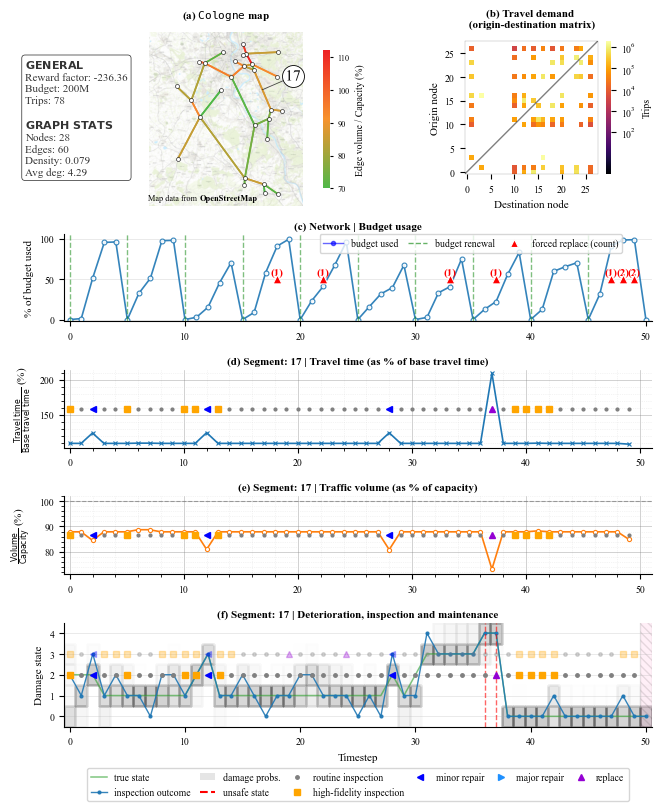

In [53]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as pe

# --- Figure: slightly shorter, single column width ---
fig = plt.figure(figsize=(6.5, 8), constrained_layout=True)

# 5 rows (map+OD, budget, det, volume, travel time), 2 cols
gs = fig.add_gridspec(
    nrows=5,
    ncols=2,
    height_ratios=[2, 1.0, 0.9, 0.9, 1.2],
    width_ratios=[1.2, 0.9],  # widen map panel
    hspace=0.1,  # extra vertical gap between panels
)

component_to_show = 17

# -------------------------------
# a) Cologne map (geolocated)
# -------------------------------
ax_map = fig.add_subplot(gs[0, 0])

# Build geodata from the environment graph
import imp_act

numpy_env = imp_act.make(ENV_NAME)
graph = numpy_env.graph

gdf_nodes = gpd.GeoDataFrame(
    {
        "id": [v["id"] for v in graph.vs],
        "geometry": [
            Point(float(v["position_x"]), float(v["position_y"])) for v in graph.vs
        ],
    },
    crs="EPSG:4326",
)

edges = []
for e in graph.es:
    v1 = graph.vs[e.source]
    v2 = graph.vs[e.target]

    if "volume" in e.attributes():
        volume = e["volume"]
    elif "base_volume" in e.attributes():
        volume = e["base_volume"]
    else:
        volume = 0.0

    if "road_edge" in e.attributes():
        edge_capacity = min(seg.capacity for seg in e["road_edge"].segments)
    else:
        edge_capacity = None
    volume_pct = (volume / edge_capacity * 100) if edge_capacity else 0.0

    edges.append(
        {
            "geometry": LineString(
                [
                    (float(v1["position_x"]), float(v1["position_y"])),
                    (float(v2["position_x"]), float(v2["position_y"])),
                ]
            ),
            "volume_pct": volume_pct,
        }
    )

gdf_edges = gpd.GeoDataFrame(edges, crs="EPSG:4326")
gdf_nodes_3857 = gdf_nodes.to_crs(epsg=3857)
gdf_edges_3857 = gdf_edges.to_crs(epsg=3857)

vpct = gdf_edges_3857["volume_pct"].fillna(0)
vmin = float(vpct.min())
vmax = float(vpct.max())
if vmin == vmax:
    vmax = vmin + 1.0

traffic_cmap = LinearSegmentedColormap.from_list(
    "traffic_signal", ["#4fb848", "#f7922d", "#ed2024"]
)
norm_v = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
edge_colors = [traffic_cmap(norm_v(v)) for v in vpct]

sm = mpl.cm.ScalarMappable(cmap=traffic_cmap, norm=norm_v)
sm.set_array([])
cax_map = inset_axes(
    ax_map,
    width="2%",
    height="80%",
    loc="center left",
    bbox_to_anchor=(0.8, 0.0, 1.0, 1.0),
    bbox_transform=ax_map.transAxes,
    borderpad=0.0,
)
cbar_map = fig.colorbar(sm, cax=cax_map)
cbar_map.outline.set_visible(False)
cbar_map.set_label("Edge volume / Capacity (%)", fontsize=7)
cbar_map.ax.tick_params(length=2, labelsize=6)

minx, miny, maxx, maxy = gdf_edges_3857.total_bounds
width = maxx - minx
height = maxy - miny
if width > height:
    pad = (width - height) / 2.0
    miny -= pad
    maxy += pad
else:
    pad = (height - width) / 2.0
    minx -= pad
    maxx += pad
zoom_pad = 0.04 * max(width, height)
minx += zoom_pad
maxx -= zoom_pad
miny += zoom_pad
maxy -= zoom_pad
ax_map.set_xlim(minx, maxx)
ax_map.set_ylim(miny, maxy)
ax_map.set_aspect("equal", adjustable="datalim")
ax_map.axis("off")

for spine in ["top", "right", "bottom", "left"]:
    ax_map.spines[spine].set_visible(True)
    ax_map.spines[spine].set_linewidth(1.2)
    ax_map.spines[spine].set_color("black")

try:
    cx.add_basemap(
        ax_map,
        source=cx.providers.Esri.WorldTopoMap,
        zorder=0,
        zoom=12,
        attribution=False,
        reset_extent=False,
    )
except Exception:
    pass

gdf_edges_3857.plot(
    ax=ax_map,
    linewidth=1.2,
    color=edge_colors,
    linestyle="solid",
    zorder=1,
)

gdf_nodes_3857.plot(
    ax=ax_map,
    marker="o",
    markersize=8,
    facecolor="white",
    edgecolor="black",
    linewidth=0.4,
    zorder=2,
)

if component_to_show < len(gdf_edges_3857):
    edge_geom = gdf_edges_3857.iloc[component_to_show].geometry
    mid_pt = edge_geom.interpolate(0.5, normalized=True)
    offset = edge_geom.parallel_offset(17_000, "right")
    label_pt = offset.interpolate(0.5, normalized=True) if not offset.is_empty else mid_pt
    ax_map.plot(
        [mid_pt.x, label_pt.x],
        [mid_pt.y, label_pt.y],
        color="black",
        linewidth=0.6,
        alpha=0.7,
        zorder=3,
    )
    ax_map.scatter(
        [label_pt.x],
        [label_pt.y],
        s=250,
        facecolors="white",
        edgecolors="black",
        linewidths=0.6,
        zorder=4,
    )
    ax_map.text(
        label_pt.x,
        label_pt.y,
        str(component_to_show),
        ha="center",
        va="center",
        fontsize=11,
        color="black",
        zorder=5,
        path_effects=[pe.withStroke(linewidth=0.8, foreground="white")],
    )

info_box = "\n".join(
    [
        "$\\bf{GENERAL}$",
        f"Reward factor: {numpy_env.config['traffic'].get('travel_time_reward_factor', 'N/A')}",
        f"Budget: {numpy_env.config['maintenance'].get('budget_amount')/1e6:.0f}M",
        f"Trips: {len(numpy_env.trips)}",
        "",
        "$\\bf{GRAPH\ STATS}$",
        f"Nodes: {graph.vcount()}",
        f"Edges: {graph.ecount()}",
        f"Density: {graph.density():.3f}",
        f"Avg deg: {float(np.mean(graph.degree())):.2f}",
    ]
)

ax_map.text(
    -0.12,
    0.85,
    info_box,
    transform=ax_map.transAxes,
    ha="left",
    va="top",
    fontsize=8,
    alpha=0.8,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, linewidth=0.5),
)

ax_map.set_title(r"(a) $\mathtt{Cologne}$ map", pad=10, fontweight="bold")

ax_map.text(
    0.26,
    0.02,
    "Map data from ",
    transform=ax_map.transAxes,
    ha="left",
    va="bottom",
    fontsize=6,
    color="black",
)
ax_map.text(
    0.42,
    0.02,
    "OpenStreetMap",
    transform=ax_map.transAxes,
    ha="left",
    va="bottom",
    fontsize=6,
    fontweight="bold",
    color="black",
)

# -------------------------------
# b) Travel demand (origin-destination matrix)
# -------------------------------
from matplotlib.gridspec import GridSpecFromSubplotSpec
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext

gs_od = GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs[0, 1], width_ratios=[28, 0.8], wspace=0.0
)
ax_od = fig.add_subplot(gs_od[0, 0])
cbar_ax = fig.add_subplot(gs_od[0, 1])
ax_od.set_aspect("equal", adjustable="box")  # square panel without extra box margin
ax_od.set_anchor("E")  # keep square matrix flush to the colorbar

ax_od.set_title(
    "(b) Travel demand \n (origin-destination matrix)", pad=10, fontweight="bold"
)

trips = np.array(env.env.trips, dtype=float)
trips[trips <= 0] = np.nan  # mask zeros

c = ax_od.pcolormesh(
    trips,
    cmap="inferno",
    norm=LogNorm(vmin=1, vmax=np.nanmax(trips)),
)

# place colorbar tight to the matrix and remove its outline
cb = fig.colorbar(c, cax=cbar_ax)
cb.outline.set_visible(False)
cb.set_label("Trips", fontsize=7)
# Hide the unused x-axis of the colorbar host axes to avoid extra ticks under the OD panel
cbar_ax.xaxis.set_visible(False)
cbar_ax.set_frame_on(False)
cb.set_ticks([1e2, 1e3, 1e4, 1e5, 1e6])
cb.ax.yaxis.set_major_formatter(LogFormatterMathtext())
cb.ax.minorticks_off()

# mark diagonal line
n = trips.shape[0]
ax_od.plot([0, n], [0, n], linestyle="-", linewidth=1, alpha=0.5, color="black")

ax_od.set_xlabel("Destination node")
ax_od.set_ylabel("Origin node")
num_trips, step = env.env.trips.shape[0], 5
idx = np.arange(0, num_trips, step)
ax_od.set_xticks(idx + 0.5)
ax_od.set_yticks(idx + 0.5)
ax_od.set_xticklabels(idx)
ax_od.set_yticklabels(idx)

# thinner spines
for spine in ["top", "right", "bottom", "left"]:
    ax_od.spines[spine].set_linewidth(0.1)

# -------------------------------
# c) Budget usage (full width)
# -------------------------------
ax_budget = fig.add_subplot(gs[1, :])
ax_budget.set_title("(c) Network | Budget usage", pad=4, fontweight="bold")
ax_budget.set_ylabel("% of budget used")
ax_budget.set_xticks([])
# Use shared method to draw budget usage styling on this axes
rp._plot_budget(single_episdode_data, ax=ax_budget)

# -------------------------------
# d) Travel time (full width) + global x-label
# -------------------------------
ax_tt = fig.add_subplot(gs[2, :])
ax_tt.set_title(
    f"(d) Segment: {component_to_show} | Travel time (as % of base travel time)",
    pad=4,
    fontweight="bold",
)
ax_tt.set_ylabel(r"$\frac{\text{Travel time}}{\text{Base travel time}}$ (%)")

# -------------------------------
# f) Traffic volume (full width)
# -------------------------------
ax_vol = fig.add_subplot(gs[3, :])
ax_vol.set_title(
    f"(e) Segment: {component_to_show} | Traffic volume (as % of capacity)",
    pad=4,
    fontweight="bold",
)
ax_vol.set_ylabel(r"$\frac{\text{Volume}}{\text{Capacity}}$ (%)")

# Use helper to render volume and travel time on combined axes
rp._plot_traffic_volume_and_travel_times(
    single_episdode_data, components_to_show=component_to_show, axes=(ax_vol, ax_tt)
)

# -------------------------------
# e) Deterioration (full width)
# -------------------------------
ax_det = fig.add_subplot(gs[4, :])
ax_det.set_title(
    f"(f) Segment: {component_to_show} | Deterioration, inspection and maintenance",
    pad=4,
    fontweight="bold",
)
ax_det.set_ylabel("Damage state")
# Draw deterioration on shared axis
rp._plot_deterioration(
    single_episdode_data,
    components_to_show=component_to_show,
    ax=ax_det,
    show_proposed_actions=True,
)
ax_det.set_xlabel("Timestep")  # global x-label lives here
ax_det.set_xticks(np.arange(0, env.env.max_timesteps + 1, 10))

# -------------------------------
# Save
# -------------------------------
fig.savefig("Figure_6.pdf", dpi=600)
plt.show()